In [1]:
using BootstrapAsymptotics
using QuadGK
using Plots
using StableRNGs: StableRNG
using ProgressBars

In [2]:
function get_additional_noise_from_kappas(kappa1, kappastar, student_dim_over_teacher_dim)
    kk1 = kappa1^2
    kkstar = kappastar^2
    lambda_minus = (1.0 - sqrt(student_dim_over_teacher_dim))^2
    lambda_plus = (1.0 + sqrt(student_dim_over_teacher_dim))^2
    
    # Function to integrate
    to_integrate(lambda_, kk1, kkstar, lambda_minus, lambda_plus) = 
        sqrt((lambda_plus - lambda_) * (lambda_ - lambda_minus)) / (kkstar + kk1 * lambda_)
    
    # Perform numerical integration
    integral, _ = quadgk(
        λ -> to_integrate(λ, kk1, kkstar, lambda_minus, lambda_plus), 
        lambda_minus, 
        lambda_plus
    )
    
    return 1.0 - kk1 * integral / (2 * π)
end

get_additional_noise_from_kappas (generic function with 1 method)

In [27]:
κ1    =  2.0 / sqrt(3* pi)
κstar = 0.200364

γ_range = 10 .^ range(-1, stop=2, length=100)
# γ_range = 0.5:0.2:3.0
Δ = 1.0
λ = 1.0

q0_list = []
q1_list = []

exp_q0_list = []
exp_q1_list = []

sample_over_teacher = 1.0

algo = PairBootstrap()

for γ in ProgressBar(γ_range)
    Δ_add = get_additional_noise_from_kappas(κ1, κstar, γ)
    
    # 
    problem = BootstrapAsymptotics.RidgeOverparametrized(
    α       = sample_over_teacher / γ,
    Δ       = Δ + Δ_add,
    λ       = λ,
    ρ       = 1.0 - Δ_add,
    κ1      = κ1,
    κstar   = κstar,
    student_over_teacher_dim   = γ
    )

    result = BootstrapAsymptotics.state_evolution(
        problem, algo, algo
    )
   push!(q0_list, result.overlaps.Q[1, 1])
   push!(q1_list, result.overlaps.Q[1, 2])

"""
   # 
   # do not include Δ_add in problem_exp as we generate the data with true Δ
   problem_exp = BootstrapAsymptotics.RidgeOverparametrized(
    α       = sample_over_teacher / γ,
    Δ       = Δ,
    λ       = λ,
    ρ       = 1.0,
    κ1      = κ1,
    κstar   = κstar,
    student_over_teacher_dim = γ
    )

    exp_overlap = BootstrapAsymptotics.overlaps_empirical(
        StableRNG(0), problem_exp, algo; teacher_dim=100, K=2
    )

    push!(exp_q0_list, exp_overlap.Q[1, 1])
    push!(exp_q1_list, exp_overlap.Q[1, 2])
"""
end

0.0%┣                                              ┫ 0/100 [00:00<00:00, -0s/it]
100.0%┣███████████████████████████████████████┫ 100/100 [00:00<00:00, 10.2kit/s]
100.0%┣████████████████████████████████████████┫ 100/100 [00:00<00:00, 9.6kit/s]


In [28]:
plot(γ_range, q0_list,label="q0", color="red")
plot!(γ_range, q1_list,label="q1", color="blue")

scatter!(γ_range, exp_q0_list , label="exp_q0", color="red")
scatter!(γ_range, exp_q1_list , label="exp_q1", color="blue")
# plot!(xscale=:log10)
# plot!(yscale=:log10)
# have the grid every power of 10 for x and y

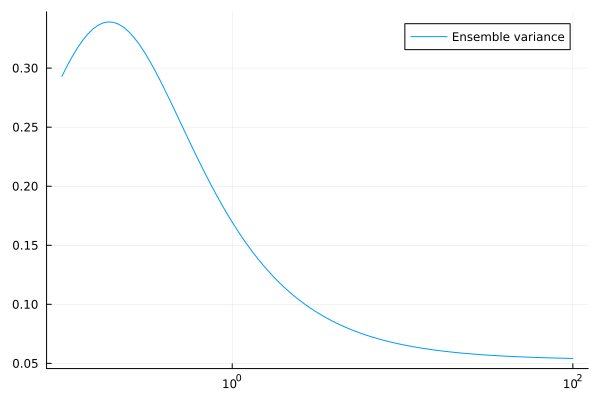

In [29]:
plot(γ_range, q0_list .- q1_list, label = "Ensemble variance")
plot!(xscale=:log10)